In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pickle
df = pd.read_csv('/content/spam.csv', encoding='latin-1')

# Dropping of unnecessary columns
df = df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'])
df = df.rename(columns={'v1': 'label', 'v2': 'message'})

#  (spam: 1, ham: 0)
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X = tfidf_vectorizer.fit_transform(df['message'])
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
with open('tfidf_vectorizer.pkl', 'wb') as file:
    pickle.dump(tfidf_vectorizer, file)
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(model, file)

print("model saved successfully.")


TF-IDF vectorizer and RandomForest model saved successfully.


In [ ]:
%%writefile app.py

import streamlit as st
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
try:
    with open('tfidf_vectorizer.pkl', 'rb') as file:
        tfidf_vectorizer = pickle.load(file)
    with open('random_forest_model.pkl', 'rb') as file:
        model = pickle.load(file)
except FileNotFoundError:
    st.error("Error: Model or vectorizer files not found.")
    st.stop()

def predict_message(message):
    message_tfidf = tfidf_vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]
    if prediction == 0:
        return "Ham (Not Spam)"
    else:
        return "Spam"
st.title("Spam Message Classifier")
st.write("Enter a message below to classify it as 'Spam' or 'Not Spam'.")

user_input = st.text_area("Message Input:", "", height=150, placeholder="Type your message here...")
if st.button("Predict"):
    if user_input:
        result = predict_message(user_input)
        st.success(f"Prediction: {result}")
    else:
        st.warning("Please enter a message to predict.")


Writing app.py


In [ ]:

!pip install streamlit pyngrok -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 90.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 99.6 MB/s eta 0:00:00


In [ ]:

from google.colab import userdata
import os
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')
if NGROK_AUTH_TOKEN:
     !ngrok authtoken $NGROK_AUTH_TOKEN
     os.environ["NGROK_AUTH_TOKEN"] = NGROK_AUTH_TOKEN
else:
     print("ngrok authtoken not set. Continuing without it. Sessions might be shorter.")

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [ ]:
from pyngrok import ngrok
import os
import subprocess
import time
#!kill -9 $(lsof -t -i:8501) 2>/dev/null || true
print("Starting Streamlit app")
!nohup streamlit run app.py > output.log 2>&1 &

if 'NGROK_AUTH_TOKEN' not in os.environ:
    try:
        from google.colab import userdata
        ngrok_token = userdata.get('NGROK_AUTH_TOKEN')
        if ngrok_token:
            ngrok.set_auth_token(ngrok_token)
            print("loaded from Colab secrets.")
        else:
            print("not found in Colab secrets.")
    except Exception as e:
        print(f"Could not load  {e}.")

print("Creating ngrok tunnel")
try:
    public_url = ngrok.connect(addr='8501', proto='http')
    print(f"Your Streamlit app is running at: {public_url}")

except Exception as e:
    print(f"Failed to create ngrok tunnel: {e}")


Starting Streamlit app in background...
Creating ngrok tunnel
Your Streamlit app is running at: NgrokTunnel: "https://noreen-defendable-claire.ngrok-free.dev" -> "http://localhost:8501"


Model Performance on Test Set:
Accuracy: 0.9794
Precision: 0.9922
Recall: 0.8533
F1-Score: 0.9176


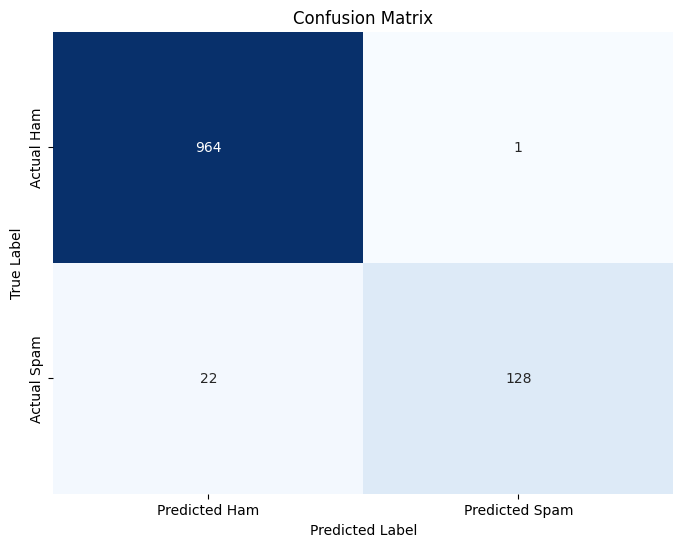

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f"Model Performance on Test Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Predicted Ham', 'Predicted Spam'],
            yticklabels=['Actual Ham', 'Actual Spam'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from ipywidgets import Textarea, Button, Output, VBox, HBox
from IPython.display import display, clear_output
def predict_message(message):
    message_tfidf = tfidf_vectorizer.transform([message])
    prediction = model.predict(message_tfidf)[0]
    if prediction == 0:
        return "Ham (Not Spam)"
    else:
        return "Spam"

# Create widgets
message_input = Textarea(
    value='',
    placeholder='Type your message here...',
    description='Message:',
    disabled=False,
    layout={'width': '80%', 'height': '100px'}
)

predict_button = Button(
    description='Predict',
    disabled=False,
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='Click to predict if the message is spam or not',
    icon='check'
)

output_area = Output()
def on_predict_button_clicked(b):
    with output_area:
        clear_output()
        if message_input.value:
            result = predict_message(message_input.value)
            print(f"Prediction: {result}")
        else:
            print("Please enter a message to predict.")
predict_button.on_click(on_predict_button_clicked)
input_box = HBox([message_input, predict_button])
gui = VBox([input_box, output_area])
display(gui)

print("GUI for spam prediction created successfully.")

GUI for spam prediction created successfully.
